# Sequential Bayesian Updating

In many applications, data arrives in **batches** rather than all at once. A sensor network reports readings every hour. A clinical trial enrolls patients in stages. An online retailer observes purchases day by day. In each case, we want to **update our beliefs incrementally** as new evidence arrives, carrying the posterior from one batch forward as the prior for the next.

This tutorial walks through ProbPipe's framework for sequential distribution transformations, starting with the simplest interface and progressively exposing the lower-level building blocks.

**Outline:**

1. [Problem setup](#1.-Problem-Setup) — Gaussian mean estimation with streaming data
2. [The quick way: IncrementalConditioner](#2.-The-Quick-Way:-IncrementalConditioner) — sequential updating in five lines
3. [Under the hood: ConditioningStep + iterate](#3.-Under-the-Hood:-ConditioningStep-+-iterate) — the building blocks
4. [Converting posteriors between steps](#4.-Converting-Posteriors-Between-Steps:-with_approximation) — keeping the posterior parametric
5. [Resampling degenerate particles](#5.-Resampling-Degenerate-Particles:-with_resampling) — tempering and SMC
6. [Tracking per-step diagnostics](#6.-Tracking-Per-Step-Diagnostics:-StepResult) — attaching auxiliary info
7. [Callbacks and early stopping](#7.-Callbacks-and-Early-Stopping) — monitoring the iteration
8. [Provenance tracking](#8.-Provenance-Tracking) — automatic lineage through the trajectory
9. [Composing and nesting](#9.-Composing-and-Nesting) — combining combinators, inner loops
10. [Summary](#10.-Summary)

## 1. Problem Setup

We'll use a simple running example throughout: estimating a 2-D mean vector $\boldsymbol{\mu}$ from noisy observations.

$$y_i \sim \mathcal{N}(\boldsymbol{\mu},\, I), \qquad \boldsymbol{\mu} \sim \mathcal{N}(\mathbf{0},\, 10\,I)$$

We generate 200 observations and split them into 4 batches of 50 — simulating data that arrives over time.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    MultivariateNormal, EmpiricalDistribution,
    from_distribution, mean, provenance_ancestors,
    sample as pp_sample,
    StepResult, TransitionTrace, iterate,
    with_approximation, with_resampling,
    ConditioningStep, IncrementalConditioner,
)
from probpipe.modeling import Likelihood

rng = np.random.default_rng(42)

In [2]:
# Ground truth
true_mu = jnp.array([2.0, -1.0])

# Generate observations and split into batches
y_all = jnp.array(rng.multivariate_normal(np.array(true_mu), np.eye(2), size=200))
batches = [y_all[i:i+50] for i in range(0, 200, 50)]

# Prior
prior = MultivariateNormal(loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name="prior")

# Likelihood: isotropic Gaussian
class GaussianLikelihood:
    def log_likelihood(self, params, data):
        residuals = jnp.asarray(data) - params[None, :]
        return -0.5 * jnp.sum(residuals ** 2)

likelihood = GaussianLikelihood()

print(f"True mu:    {true_mu}")
print(f"Batches:    {len(batches)} x {batches[0].shape[0]} observations")
print(f"Prior mean: {mean(prior)}")

True mu:    [ 2. -1.]
Batches:    4 x 50 observations
Prior mean: [0. 0.]


Throughout this notebook we use a lightweight **mock conditioning function** that computes the conjugate Gaussian posterior analytically. In practice, you'd use ProbPipe's `condition_on` which dispatches to NUTS, HMC, or another inference backend.

In [3]:
def mock_condition(model, data, **kwargs):
    """Conjugate Gaussian posterior (known unit variance)."""
    prior_dist = model["parameters"]
    prior_mean = mean(prior_dist)
    data = jnp.asarray(data)
    n = data.shape[0]
    prior_prec = jnp.linalg.inv(jnp.array([[10., 0.], [0., 10.]]))
    data_prec = n * jnp.eye(2)
    post_prec = prior_prec + data_prec
    post_cov = jnp.linalg.inv(post_prec)
    post_mean = post_cov @ (prior_prec @ prior_mean + data_prec @ jnp.mean(data, axis=0))
    key = jax.random.PRNGKey(hash(str(data[:3])) % (2**31))
    samples = jax.random.multivariate_normal(key, post_mean, post_cov, shape=(500,))
    return EmpiricalDistribution(samples, name="posterior")

We also define a helper that wraps `mock_condition` to return a parametric `MultivariateNormal` instead of samples — this lets each posterior serve cleanly as the next step's prior.

In [4]:
def approx_condition(model, data, **kwargs):
    """Condition, then moment-match to MultivariateNormal."""
    post = mock_condition(model, data, **kwargs)
    return from_distribution(post, MultivariateNormal, name="posterior")

---

## 2. The Quick Way: IncrementalConditioner

For the common case — a fixed likelihood and a sequence of data batches — `IncrementalConditioner` handles everything in a few lines. It builds a model from the current posterior + likelihood, conditions on the next batch, and repeats.

In [5]:
conditioner = IncrementalConditioner(
    prior=prior,
    likelihood=likelihood,
    condition_fn=approx_condition,
)

trace = conditioner.update(data_batches=batches)

print(f"Batches processed: {len(trace)}")
print(f"Final posterior mean: {mean(trace.final)}")
print(f"True mu:             {true_mu}")

Batches processed: 4
Final posterior mean: [ 2.151907  -0.9534985]
True mu:             [ 2. -1.]


W0406 16:10:21.795274 3276960 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


The result is a `TransitionTrace` — a trajectory that holds the initial prior and each successive posterior. We can visualize how the posterior concentrates around the true value as more data is observed.

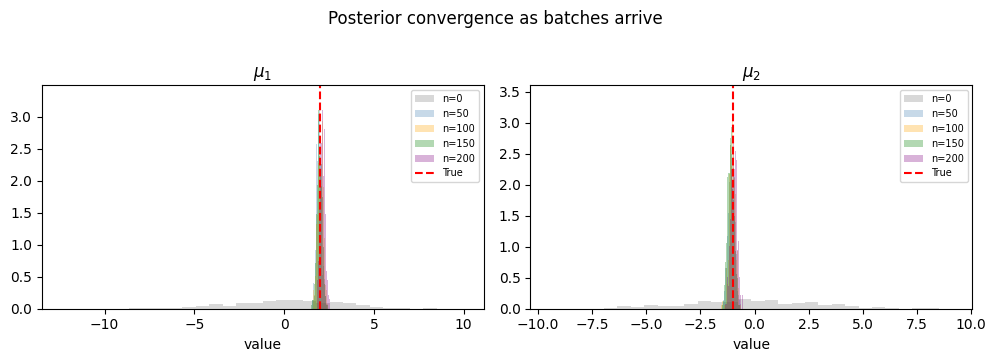

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['gray', 'steelblue', 'orange', 'green', 'purple']
for i, dist in enumerate(trace.distributions):
    n_seen = i * 50
    samples = np.array(pp_sample(dist, key=jax.random.PRNGKey(i), sample_shape=(500,)))
    ax1.hist(samples[:, 0], bins=30, density=True,
             alpha=0.3, color=colors[i], label=f'n={n_seen}')
    ax2.hist(samples[:, 1], bins=30, density=True,
             alpha=0.3, color=colors[i], label=f'n={n_seen}')

for ax, true_val in [(ax1, true_mu[0]), (ax2, true_mu[1])]:
    ax.axvline(float(true_val), color='red', linestyle='--', label=f'True')
    ax.set_xlabel('value')
    ax.legend(fontsize=7)

ax1.set_title(r'$\mu_1$')
ax2.set_title(r'$\mu_2$')
fig.suptitle('Posterior convergence as batches arrive', y=1.02)
plt.tight_layout()
plt.show()

The prior (gray, n=0) is wide and centered at zero. With each batch the posterior sharpens and shifts toward the true $\boldsymbol{\mu} = (2, -1)$.

For many workflows, `IncrementalConditioner` is all you need. The rest of this tutorial shows the building blocks it's built from, which give you more control.

---

## 3. Under the Hood: ConditioningStep + iterate

`IncrementalConditioner` is a thin wrapper around two primitives:

- **`ConditioningStep`** — a `WorkflowFunction` that takes a distribution and a data batch, builds a `SimpleModel`, and conditions on the data. It's the *step function*.
- **`iterate`** — a fold that applies a step function repeatedly over a sequence of inputs, collecting a `TransitionTrace`.

Using these directly gives you access to combinators, custom step functions, and callbacks.

In [7]:
# Build a step function from the likelihood + conditioning function
step = ConditioningStep(likelihood, condition_fn=approx_condition)

# Fold it over the data batches
trace = iterate(step, prior, batches)

print(f"Steps: {len(trace)}")
for i, dist in enumerate(trace.distributions):
    print(f"  [{i}] {type(dist).__name__:25s} mean = {mean(dist)}")
print(f"\nTrue mu: {true_mu}")

Steps: 4
  [0] MultivariateNormal        mean = [0. 0.]
  [1] MultivariateNormal        mean = [ 1.9481918 -1.0682254]
  [2] MultivariateNormal        mean = [ 2.009648  -1.0266315]
  [3] MultivariateNormal        mean = [ 1.9709029 -1.0877024]
  [4] MultivariateNormal        mean = [ 2.151907  -0.9534985]

True mu: [ 2. -1.]


The key insight is that **a step function is just a callable**: `(Distribution, input) -> Distribution`. There's no base class required. `ConditioningStep` is a `WorkflowFunction` subclass because it needs construction-time configuration (the likelihood and condition function), but for simple cases a plain function works fine.

Here's a minimal example with a plain function that shifts samples by an offset:

In [8]:
def shift_step(dist, offset):
    """Shift all samples by an offset."""
    return EmpiricalDistribution(dist.samples + offset)

start = EmpiricalDistribution(jnp.zeros((200, 2)), name="start")
trace = iterate(shift_step, start, [1.0, 0.5, -0.3])

print(f"Steps:      {len(trace)}")
print(f"Final mean: {mean(trace.final)}")
print(f"Expected:   {1.0 + 0.5 - 0.3}")

Steps:      3
Final mean: [1.2000003 1.2000003]
Expected:   1.2


---

## 4. Converting Posteriors Between Steps: `with_approximation`

In real inference, each conditioning step typically returns MCMC samples (an `EmpiricalDistribution`). But we often want the *next* prior to be parametric — a `MultivariateNormal` fit to those samples — so the model stays well-defined.

The `with_approximation` combinator wraps a step function to automatically convert its output after each step. It also stores the pre-conversion distribution in `info["pre_approximation"]` so you don't lose the raw samples.

In [9]:
# ConditioningStep with mock_condition returns EmpiricalDistribution
raw_step = ConditioningStep(likelihood, condition_fn=mock_condition)

# Wrap it: after each step, moment-match to MultivariateNormal
approx_step = with_approximation(raw_step, MultivariateNormal, name="posterior")

trace = iterate(approx_step, prior, batches)

for i, result in enumerate(trace):
    dist = result.distribution
    pre = result.info["pre_approximation"]
    print(f"  Step {i}: {type(pre).__name__:30s} -> {type(dist).__name__}")

print(f"\nAll posteriors are parametric: {all(isinstance(r.distribution, MultivariateNormal) for r in trace)}")

  Step 0: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 1: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 2: ArrayEmpiricalDistribution     -> MultivariateNormal
  Step 3: ArrayEmpiricalDistribution     -> MultivariateNormal

All posteriors are parametric: True


Since `with_approximation` returns a `WorkflowFunction`, it appears as a named node in ProbPipe's workflow DAG. Combinators compose naturally — you can stack them (see [Section 9](#9.-Composing-and-Nesting)).

---

## 5. Resampling Degenerate Particles: `with_resampling`

In **tempering** and **SMC** algorithms, particles carry importance weights that get updated at each step. As the target distribution sharpens, a few particles tend to dominate — the *effective sample size* (ESS) collapses and the approximation degrades.

`with_resampling` monitors ESS after each step and, when `ESS/N` drops below a threshold, resamples to produce equally-weighted particles. It records `"ess"`, `"ess_ratio"`, and `"resampled"` in the step info.

Here's a toy tempering example: particles are progressively reweighted toward a target at $(2, 2)$.

In [10]:
def tempering_step(dist, beta_increment):
    """Reweight particles by a tempered quadratic likelihood."""
    samples = dist.samples
    target = jnp.array([2.0, 2.0])
    log_lik = -0.5 * jnp.sum((samples - target) ** 2, axis=1)
    old_log_w = dist._w.log_normalized
    new_log_w = old_log_w + beta_increment * log_lik
    return EmpiricalDistribution(samples, log_weights=new_log_w)

# Wide prior particles
key = jax.random.PRNGKey(0)
prior_samples = jax.random.normal(key, shape=(500, 2)) * 3.0
particles = EmpiricalDistribution(prior_samples, name="prior_particles")

# Temper in 5 equal increments: beta goes 0 -> 1
betas = [0.2] * 5

# Without resampling
trace_no = iterate(tempering_step, particles, betas)

# With resampling (ESS/N < 50% triggers resampling)
trace_yes = iterate(
    with_resampling(tempering_step, ess_threshold=0.5),
    particles, betas,
)

In [11]:
# Compare ESS trajectories
ess_no = [float(d.effective_sample_size) for d in trace_no.distributions[1:]]
ess_yes = trace_yes.info_values('ess')
resampled = trace_yes.info_values('resampled')

print("Without resampling:")
for i, e in enumerate(ess_no):
    print(f"  Step {i}: ESS = {e:5.1f} ({e/500*100:2.0f}%)")

print("\nWith resampling (threshold = 50%):")
for i, (e, r) in enumerate(zip(ess_yes, resampled)):
    tag = ' [resampled]' if r else ''
    print(f"  Step {i}: ESS = {e:5.1f} ({e/500*100:2.0f}%){tag}")

Without resampling:
  Step 0: ESS = 245.5 (49%)
  Step 1: ESS = 160.4 (32%)
  Step 2: ESS = 118.8 (24%)
  Step 3: ESS =  93.6 (19%)
  Step 4: ESS =  76.5 (15%)

With resampling (threshold = 50%):
  Step 0: ESS = 245.5 (49%) [resampled]
  Step 1: ESS = 420.3 (84%)
  Step 2: ESS = 334.4 (67%)
  Step 3: ESS = 271.8 (54%)
  Step 4: ESS = 226.4 (45%) [resampled]


Without resampling, ESS drops monotonically. With resampling, it recovers after each resample event. The effect on the particle cloud is dramatic:

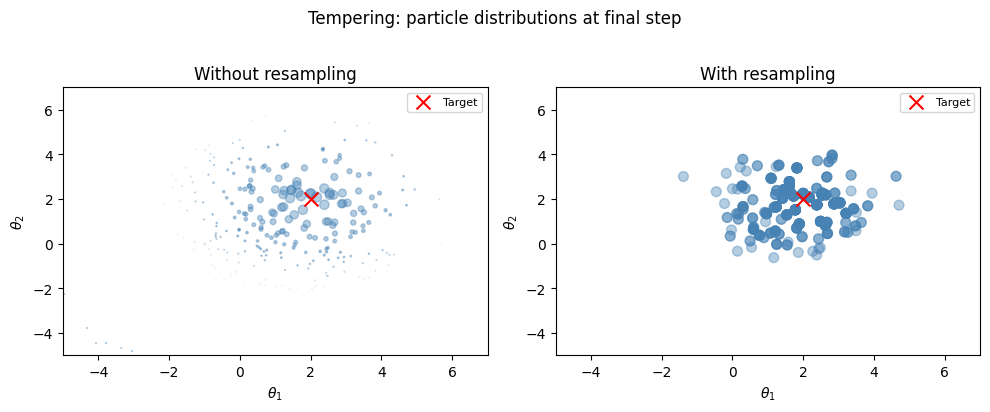

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, tr, title in [(axes[0], trace_no, 'Without resampling'),
                       (axes[1], trace_yes, 'With resampling')]:
    final = tr.final
    s = np.array(final.samples)
    w = np.array(final.weights)
    sizes = w / w.max() * 50
    ax.scatter(s[:, 0], s[:, 1], s=sizes, alpha=0.4, c='steelblue')
    ax.scatter([2.0], [2.0], c='red', marker='x', s=100, zorder=5, label='Target')
    ax.set_xlim(-5, 7)
    ax.set_ylim(-5, 7)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Tempering: particle distributions at final step', y=1.02)
plt.tight_layout()
plt.show()

Without resampling, most particles (sized by weight) are negligible — a few dominate. With resampling, particles are redistributed to equally-weighted copies of the high-probability particles, keeping the approximation healthy.

---

## 6. Tracking Per-Step Diagnostics: StepResult

When a step function returns a `StepResult` instead of a bare `Distribution`, it can attach an `info` dict with arbitrary diagnostics. The `TransitionTrace` collects these and provides accessors.

In [13]:
def shift_with_diagnostics(dist, offset):
    """Shift samples and record diagnostics."""
    new_samples = dist.samples + offset
    new_dist = EmpiricalDistribution(new_samples)
    return StepResult(
        distribution=new_dist,
        info={"offset": float(offset), "sample_mean": float(jnp.mean(new_samples))},
    )

start = EmpiricalDistribution(jnp.zeros((200, 2)))
trace = iterate(shift_with_diagnostics, start, [1.0, 2.0, 3.0])

# Per-step info dicts
for i, info in enumerate(trace.infos):
    print(f"  Step {i}: offset={info['offset']:.1f}, sample_mean={info['sample_mean']:.1f}")

# Extract a single key across all steps
print(f"\nAll offsets: {trace.info_values('offset')}")

  Step 0: offset=1.0, sample_mean=1.0
  Step 1: offset=2.0, sample_mean=3.0
  Step 2: offset=3.0, sample_mean=6.0

All offsets: [1.0, 2.0, 3.0]


`TransitionTrace` also supports iteration and indexing:

In [14]:
# Indexing
print(f"First result:  {trace[0].info}")
print(f"Last result:   {trace[-1].info}")

# Iteration
print(f"\nIterating over trace:")
for result in trace:
    print(f"  offset={result.info['offset']}, mean={result.info['sample_mean']:.1f}")

# Properties
print(f"\nlen(trace):              {len(trace)}")
print(f"len(trace.distributions): {len(trace.distributions)}  (includes initial)")
print(f"trace.final is trace[-1]: {trace.final is trace[-1].distribution}")

First result:  {'offset': 1.0, 'sample_mean': 1.0}
Last result:   {'offset': 3.0, 'sample_mean': 6.0}

Iterating over trace:
  offset=1.0, mean=1.0
  offset=2.0, mean=3.0
  offset=3.0, mean=6.0

len(trace):              3
len(trace.distributions): 4  (includes initial)
trace.final is trace[-1]: True


---

## 7. Callbacks and Early Stopping

Pass a `callback` to `iterate` for logging or early termination. It receives `(step_index, step_result)` after each step. Return `False` to stop early.

In [15]:
def stop_when_converged(i, result):
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Step {i}: mean = {m:.2f}")
    if m > 3.0:
        print(f"  -> Stopping (mean exceeded 3.0)")
        return False

start = EmpiricalDistribution(jnp.zeros((200, 2)))
trace = iterate(shift_step, start, [1.0, 1.5, 2.0, 2.5], callback=stop_when_converged)
print(f"Steps completed: {len(trace)} of 4")

  Step 0: mean = 1.00
  Step 1: mean = 2.50
  Step 2: mean = 4.50
  -> Stopping (mean exceeded 3.0)
Steps completed: 3 of 4


---

## 8. Provenance Tracking

`iterate` automatically attaches provenance to each step's output, linking it to the previous distribution. This forms a chain that `provenance_ancestors` can traverse. If a step function sets its own provenance, `iterate` respects it.

In [16]:
start = EmpiricalDistribution(jnp.zeros((100, 2)), name="start")
trace = iterate(shift_step, start, [1.0, 2.0, 3.0])

# Each step links to the previous distribution
for i, result in enumerate(trace):
    src = result.distribution.source
    parent_name = src.parents[0].name or type(src.parents[0]).__name__
    print(f"  Step {i}: operation='{src.operation}', parent='{parent_name}'")

# Traverse the full ancestor chain from the final distribution
ancestors = provenance_ancestors(trace.final)
print(f"\nAncestor chain from final: {[a.name or type(a).__name__ for a in ancestors]}")

  Step 0: operation='iterate', parent='start'
  Step 1: operation='iterate', parent='ArrayEmpiricalDistribution'
  Step 2: operation='iterate', parent='ArrayEmpiricalDistribution'

Ancestor chain from final: ['ArrayEmpiricalDistribution', 'ArrayEmpiricalDistribution', 'start']


---

## 9. Composing and Nesting

### Stacking combinators

Combinators compose by wrapping: `with_approximation(with_resampling(step, ...), ...)`. Each combinator adds a layer of post-processing while preserving the step function's core behavior.

In [17]:
raw_step = ConditioningStep(likelihood, condition_fn=mock_condition)

# Stack: resample if ESS drops, then approximate as MVN
composed_step = with_approximation(
    with_resampling(raw_step, ess_threshold=0.3),
    MultivariateNormal, name="posterior",
)

trace = iterate(composed_step, prior, batches)

print(f"All posteriors parametric: {all(isinstance(r.distribution, MultivariateNormal) for r in trace)}")
print(f"Final mean: {mean(trace.final)}")
print(f"True mu:    {true_mu}")

All posteriors parametric: True
Final mean: [ 2.151907  -0.9534985]
True mu:    [ 2. -1.]


### Nested iteration

Step functions can call `iterate` internally. This enables algorithms like tempering-within-conditioning, where each outer step runs an inner loop.

In [18]:
def inner_step(dist, value):
    return EmpiricalDistribution(dist.samples + value)

def outer_step(dist, batch):
    """Each outer step runs an inner iterate loop."""
    inner_trace = iterate(inner_step, dist, batch)
    return StepResult(
        distribution=inner_trace.final,
        info={"inner_steps": len(inner_trace), "total_shift": sum(batch)},
    )

start = EmpiricalDistribution(jnp.zeros((100, 2)))
trace = iterate(outer_step, start, [[0.1, 0.2, 0.3], [0.4, 0.5]])

for i, result in enumerate(trace):
    info = result.info
    m = float(jnp.mean(result.distribution.samples))
    print(f"  Outer {i}: {info['inner_steps']} inner steps, shift={info['total_shift']:.1f}, mean={m:.2f}")

expected = 0.1 + 0.2 + 0.3 + 0.4 + 0.5
print(f"Final mean: {float(jnp.mean(trace.final.samples)):.2f} (expected {expected:.2f})")

  Outer 0: 3 inner steps, shift=0.6, mean=0.60
  Outer 1: 2 inner steps, shift=0.9, mean=1.50
Final mean: 1.50 (expected 1.50)


---

## 10. Summary

| Component | What it does | When to use |
|-----------|-------------|-------------|
| `IncrementalConditioner` | Sequential conditioning in one call | Fixed likelihood, simple sequential updating |
| `ConditioningStep` | One step of Bayesian conditioning | When you need combinator composition or custom callbacks |
| `iterate` | Fold a step function over inputs | Always — the core iteration primitive |
| `with_approximation` | Convert output type after each step | MCMC posterior -> parametric for next prior |
| `with_resampling` | Resample when ESS degenerates | Tempering, SMC, importance sampling |
| `StepResult` | Pair a distribution with diagnostics | When your step produces ESS, timing, etc. |
| `TransitionTrace` | Access the full trajectory | Inspecting convergence, plotting, provenance |

**Key ideas:**

- A step function is any callable `(Distribution, input) -> Distribution | StepResult`.
- Combinators compose: `with_approximation(with_resampling(step, ...), ...)`.
- `iterate` is itself a `WorkflowFunction` — it participates in ProbPipe's orchestration like any other operation.
- Provenance is automatic: each step's output links to its parent.